In [1]:
# Week 4: Machine Learning Model Development and Evaluation
# Student Performance Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Step 3: Data Quality Check

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows:
0

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2

In [4]:
# Step 4: Feature Engineering

# Calculate average score
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

# Create performance categories
def performance_category(score):
    if score < 60:
        return "Low"
    elif score <= 75:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["average_score"].apply(performance_category)

# Display the new columns
print("Feature engineering completed successfully!\n")

print(df[[
    "math score",
    "reading score",
    "writing score",
    "average_score",
    "performance_category"
]].head(10))

Feature engineering completed successfully!

   math score  reading score  writing score  average_score  \
0          72             72             74      72.666667   
1          69             90             88      82.333333   
2          90             95             93      92.666667   
3          47             57             44      49.333333   
4          76             78             75      76.333333   
5          71             83             78      77.333333   
6          88             95             92      91.666667   
7          40             43             39      40.666667   
8          64             64             67      65.000000   
9          38             60             50      49.333333   

  performance_category  
0               Medium  
1                 High  
2                 High  
3                  Low  
4                 High  
5                 High  
6                 High  
7                  Low  
8               Medium  
9                  Low

In [5]:
# Step 5: Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

# Create a copy for machine learning
ml_df = df.copy()

# Columns that contain categorical data
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

# Encode categorical columns
label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    ml_df[column] = le.fit_transform(ml_df[column])
    label_encoders[column] = le

print("Categorical encoding completed successfully!\n")

# Display encoded data
print(ml_df.head())

print("\nData Types after encoding:")
print(ml_df.dtypes)

Categorical encoding completed successfully!

   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  \
0                        1          72             72             74   
1                        0          69             90             88   
2                        1          90             95             93   
3                        1          47             57             44   
4                        1          76             78             75   

   average_score performance_category  
0      72.666667               Medium  
1      82.333333                 High  
2      92.

In [6]:
# Step 6: Define Features and Target

# Features used to predict student performance
feature_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "math score",
    "reading score"
]

X = ml_df[feature_columns]

# Target variable: writing score
y = ml_df["writing score"]

print("Features and target defined successfully!\n")

print("Feature shape (X):", X.shape)
print("Target shape (y):", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nFirst 5 target values:")
print(y.head())

Features and target defined successfully!

Feature shape (X): (1000, 7)
Target shape (y): (1000,)

Feature columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score']

First 5 target values:
0    74
1    88
2    93
3    44
4    75
Name: writing score, dtype: int64


In [7]:
# Step 4: Split the dataset into Training and Testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Data splitting completed successfully!")
print("Training features shape :", X_train.shape)
print("Testing features shape  :", X_test.shape)
print("Training target shape   :", y_train.shape)
print("Testing target shape    :", y_test.shape)

Data splitting completed successfully!
Training features shape : (800, 7)
Testing features shape  : (200, 7)
Training target shape   : (800,)
Testing target shape    : (200,)


In [8]:
# Step 5: Linear Regression Model Training

from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

# Display model coefficients
print("\nModel coefficients:")
print(linear_model.coef_)

print("\nModel intercept:")
print(linear_model.intercept_)

Linear Regression model trained successfully!

Model coefficients:
[-5.57730016  0.06882996 -0.21025098  0.38175093 -3.28931541  0.26550903
  0.68943656]

Model intercept:
7.749231835989548


In [9]:
# Step 6: Model Prediction and Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = linear_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Evaluation")
print("=" * 45)
print(f"Mean Absolute Error (MAE)  : {mae:.4f}")
print(f"Mean Squared Error (MSE)   : {mse:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R² Score                   : {r2:.4f}")

Linear Regression Model Evaluation
Mean Absolute Error (MAE)  : 3.3345
Mean Squared Error (MSE)   : 16.5880
Root Mean Squared Error    : 4.0728
R² Score                   : 0.9312


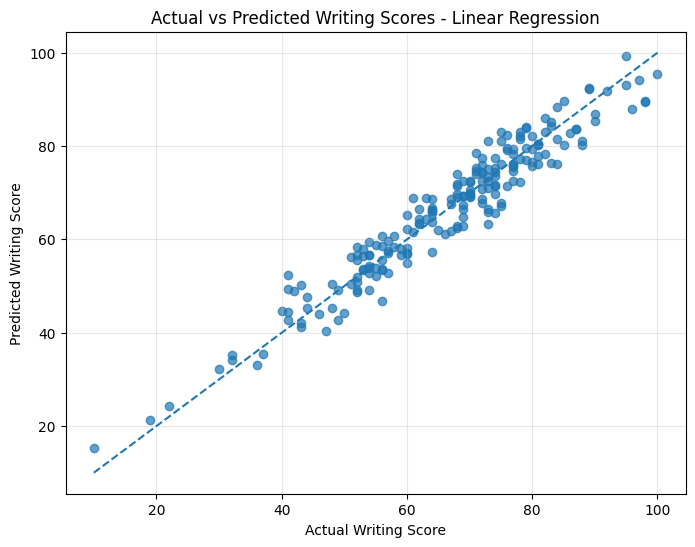

In [10]:
# Step 7: Actual vs Predicted Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Writing Score")
plt.ylabel("Predicted Writing Score")
plt.title("Actual vs Predicted Writing Scores - Linear Regression")

plt.grid(True, alpha=0.3)
plt.show()

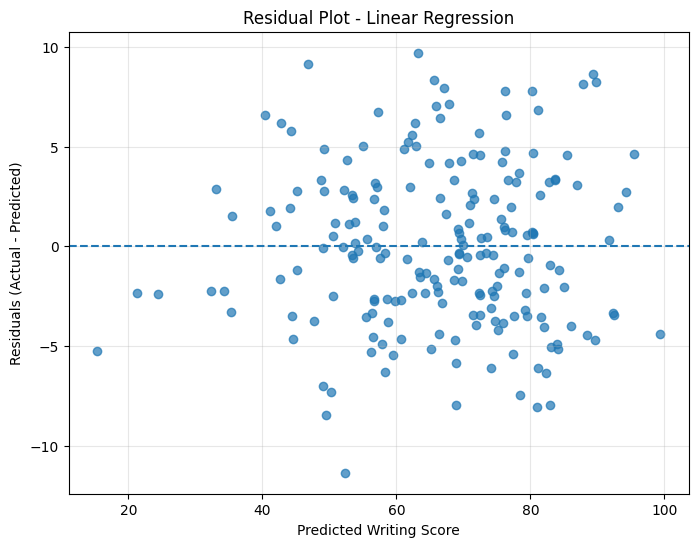

In [11]:
# Step 8: Residual/Error Analysis

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

# Zero-error reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Writing Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")

plt.grid(True, alpha=0.3)
plt.show()

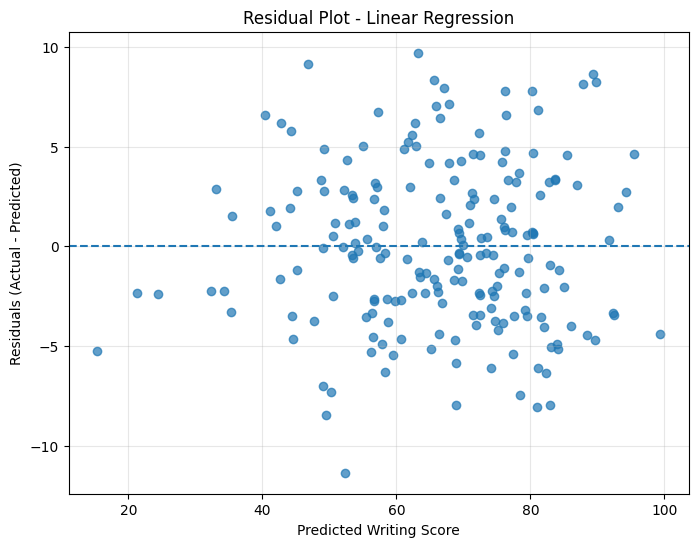

In [12]:
# Step 8: Residual / Error Analysis

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Writing Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")

plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Step 9: Decision Tree Regression Model

from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree model
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully!")

Decision Tree Regression model trained successfully!


In [14]:
# Step 10: Decision Tree Prediction and Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Calculate evaluation metrics
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression Model Evaluation")
print("=" * 50)
print(f"Mean Absolute Error (MAE)  : {mae_tree:.4f}")
print(f"Mean Squared Error (MSE)   : {mse_tree:.4f}")
print(f"Root Mean Squared Error    : {rmse_tree:.4f}")
print(f"R² Score                   : {r2_tree:.4f}")

Decision Tree Regression Model Evaluation
Mean Absolute Error (MAE)  : 3.9146
Mean Squared Error (MSE)   : 24.5673
Root Mean Squared Error    : 4.9565
R² Score                   : 0.8981


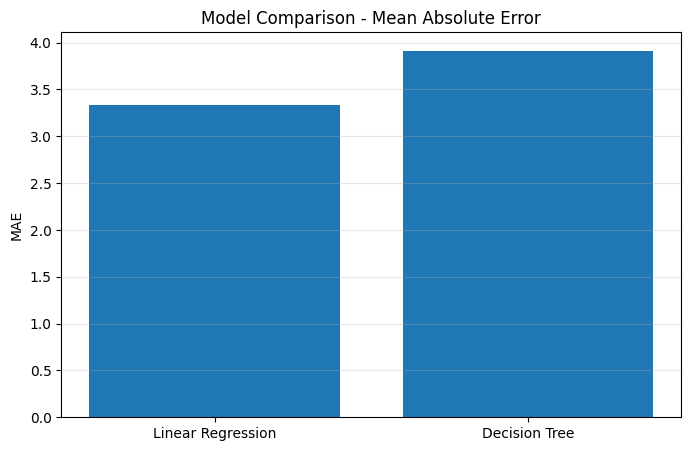

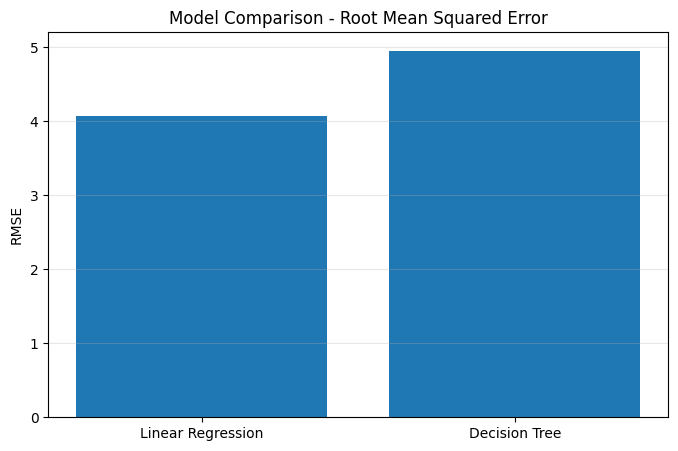

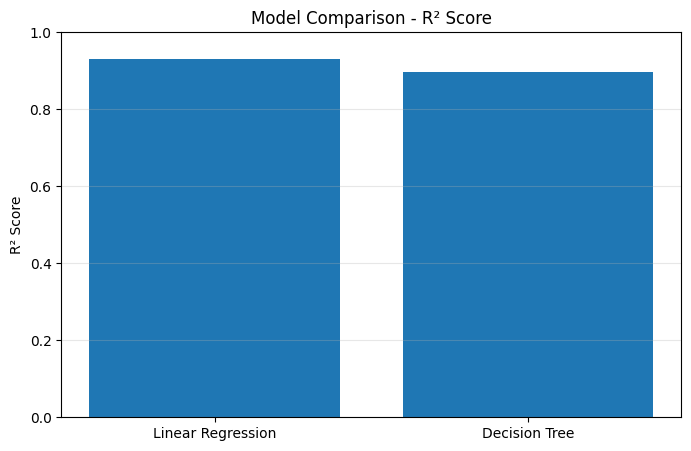

In [15]:
# Step 11: Model Performance Comparison

import matplotlib.pyplot as plt
import numpy as np

models = ["Linear Regression", "Decision Tree"]

mae_scores = [mae, mae_tree]
rmse_scores = [rmse, rmse_tree]
r2_scores = [r2, r2_tree]

# MAE Comparison
plt.figure(figsize=(8, 5))
plt.bar(models, mae_scores)
plt.ylabel("MAE")
plt.title("Model Comparison - Mean Absolute Error")
plt.grid(axis="y", alpha=0.3)
plt.show()

# RMSE Comparison
plt.figure(figsize=(8, 5))
plt.bar(models, rmse_scores)
plt.ylabel("RMSE")
plt.title("Model Comparison - Root Mean Squared Error")
plt.grid(axis="y", alpha=0.3)
plt.show()

# R² Comparison
plt.figure(figsize=(8, 5))
plt.bar(models, r2_scores)
plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [16]:
# ============================================
# FINAL MODEL COMPARISON TABLE
# ============================================

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regression'],
    'MAE': [3.3345, 3.9146],
    'MSE': [16.5880, 24.5673],
    'RMSE': [4.0728, 4.9565],
    'R2 Score': [0.9312, 0.8981]
})

print("FINAL MODEL COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))

# Identify best model
best_model = comparison.loc[comparison['R2 Score'].idxmax(), 'Model']

print("\nBest Performing Model:", best_model)
print("Reason: Highest R² score and lowest prediction errors.")

FINAL MODEL COMPARISON
                   Model    MAE     MSE   RMSE  R2 Score
       Linear Regression 3.3345 16.5880 4.0728    0.9312
Decision Tree Regression 3.9146 24.5673 4.9565    0.8981

Best Performing Model: Linear Regression
Reason: Highest R² score and lowest prediction errors.


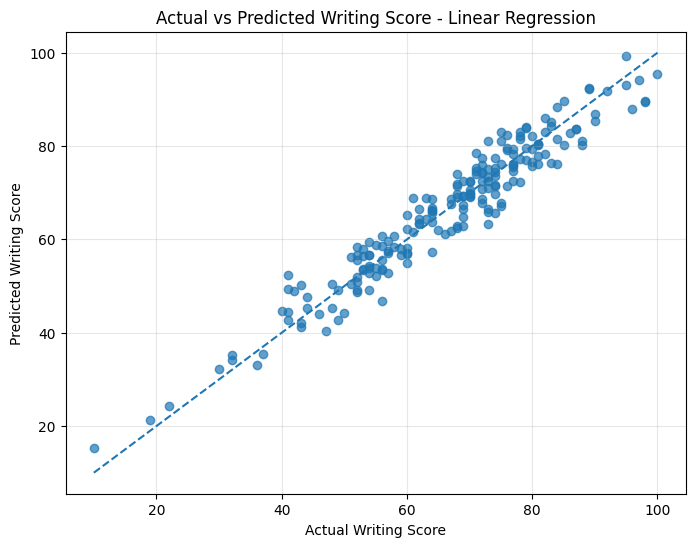

In [17]:
# ============================================
# ACTUAL VS PREDICTED - BEST MODEL
# ============================================

import matplotlib.pyplot as plt

# Predictions from Linear Regression
y_pred_best = linear_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_best, alpha=0.7)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Writing Score')
plt.ylabel('Predicted Writing Score')
plt.title('Actual vs Predicted Writing Score - Linear Regression')

plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# ============================================
# OVERFITTING / UNDERFITTING CHECK
# ============================================

# Training predictions
y_train_pred_lr = linear_model.predict(X_train)

# Training R²
train_r2_lr = r2_score(y_train, y_train_pred_lr)

# Testing R²
test_r2_lr = r2_score(y_test, y_pred_best)

print("OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 50)
print(f"Training R² Score : {train_r2_lr:.4f}")
print(f"Testing R² Score  : {test_r2_lr:.4f}")
print(f"Difference        : {train_r2_lr - test_r2_lr:.4f}")

if abs(train_r2_lr - test_r2_lr) < 0.10:
    print("\nConclusion: No significant overfitting detected.")
    print("The model generalizes well to unseen data.")
else:
    print("\nConclusion: Some difference between training and testing performance.")
    print("Further validation or regularization may be considered.")

OVERFITTING / UNDERFITTING ANALYSIS
Training R² Score : 0.9418
Testing R² Score  : 0.9312
Difference        : 0.0106

Conclusion: No significant overfitting detected.
The model generalizes well to unseen data.


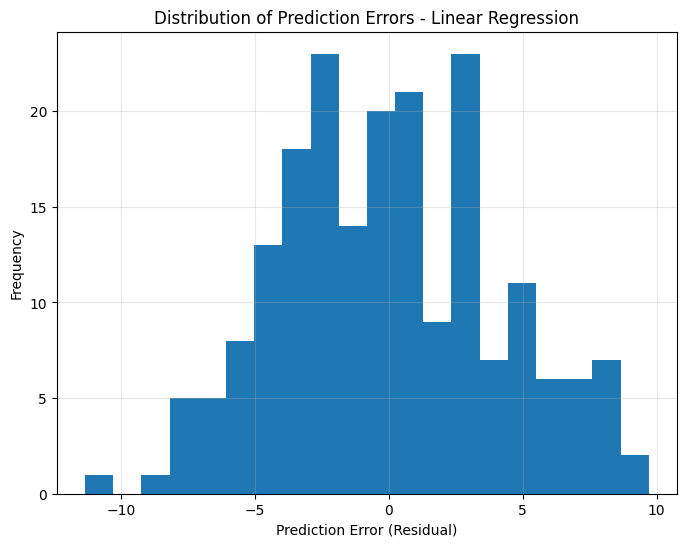

In [19]:
# ============================================
# PREDICTION ERROR DISTRIBUTION
# ============================================

residuals = y_test - y_pred_best

plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=20)

plt.xlabel("Prediction Error (Residual)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors - Linear Regression")

plt.grid(True, alpha=0.3)
plt.show()

LINEAR REGRESSION FEATURE COEFFICIENTS
                    Feature  Coefficient
                     gender    -5.577300
    test preparation course    -3.289315
              reading score     0.689437
                      lunch     0.381751
                 math score     0.265509
parental level of education    -0.210251
             race/ethnicity     0.068830


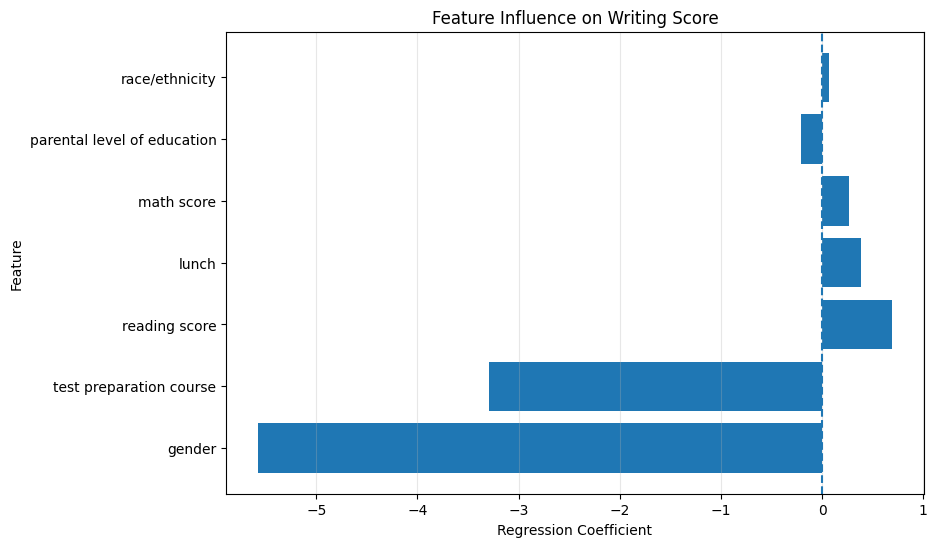

In [20]:
# ============================================
# FEATURE COEFFICIENT ANALYSIS
# ============================================

feature_names = X.columns
coefficients = linear_model.coef_

coefficient_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coefficient_df = coefficient_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print("LINEAR REGRESSION FEATURE COEFFICIENTS")
print("=" * 60)
print(coefficient_df.to_string(index=False))

# Visualization
plt.figure(figsize=(9, 6))

plt.barh(
    coefficient_df['Feature'],
    coefficient_df['Coefficient']
)

plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Influence on Writing Score")

plt.axvline(0, linestyle='--')
plt.grid(True, axis='x', alpha=0.3)

plt.show()

In [21]:
# FINAL PREDICTION USING LINEAR REGRESSION

# Example student data
sample_student = [[1, 2, 3, 1, 0, 75, 78]]

# Predict writing score
predicted_score = linear_model.predict(sample_student)

print("FINAL PREDICTION")
print("=" * 40)
print("Predicted Writing Score:", round(predicted_score[0], 2))

FINAL PREDICTION
Predicted Writing Score: 75.75


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
# ============================================
# FINAL PROJECT SUMMARY
# ============================================

print("WEEK 4 MACHINE LEARNING PROJECT - FINAL SUMMARY")
print("=" * 60)

print("\nBest Performing Model : Linear Regression")
print("MAE                   : 3.3345")
print("MSE                   : 16.5880")
print("RMSE                  : 4.0728")
print("R2 Score              : 0.9312")

print("\nOverfitting Analysis")
print("Training R2 Score     : 0.9418")
print("Testing R2 Score      : 0.9312")
print("R2 Difference         : 0.0106")

print("\nConclusion")
print("The Linear Regression model performed better than")
print("the Decision Tree Regression model.")
print("The model showed good generalization with no significant")
print("overfitting and achieved strong predictive performance.")

WEEK 4 MACHINE LEARNING PROJECT - FINAL SUMMARY

Best Performing Model : Linear Regression
MAE                   : 3.3345
MSE                   : 16.5880
RMSE                  : 4.0728
R2 Score              : 0.9312

Overfitting Analysis
Training R2 Score     : 0.9418
Testing R2 Score      : 0.9312
R2 Difference         : 0.0106

Conclusion
The Linear Regression model performed better than
the Decision Tree Regression model.
The model showed good generalization with no significant
overfitting and achieved strong predictive performance.
